In [1]:
from IPython.display import display

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from time import time
import seaborn as sns
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = np.random.seed(0)

In [2]:
def parser(s):
    return datetime.strptime(s, '%Y-%m-%d')

In [3]:

#read data
catfish_sales = pd.read_csv('catfish.csv', parse_dates=[0], index_col=0, date_parser=parser)
#infer the frequency of the data
catfish_sales = catfish_sales.asfreq(pd.infer_freq(catfish_sales.index))

In [4]:
catfish_sales.head()

,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


In [5]:
catfish_sales.tail()

,Total
Date,
2012-08-01,14442
2012-09-01,13422
2012-10-01,13795
2012-11-01,13352
2012-12-01,12716


In [6]:
#transform
start_date = datetime(1996,1,1)
end_date = datetime(2008,1,1)
lim_catfish_sales = catfish_sales[start_date:end_date]

Text(0, 0.5, 'Sales')

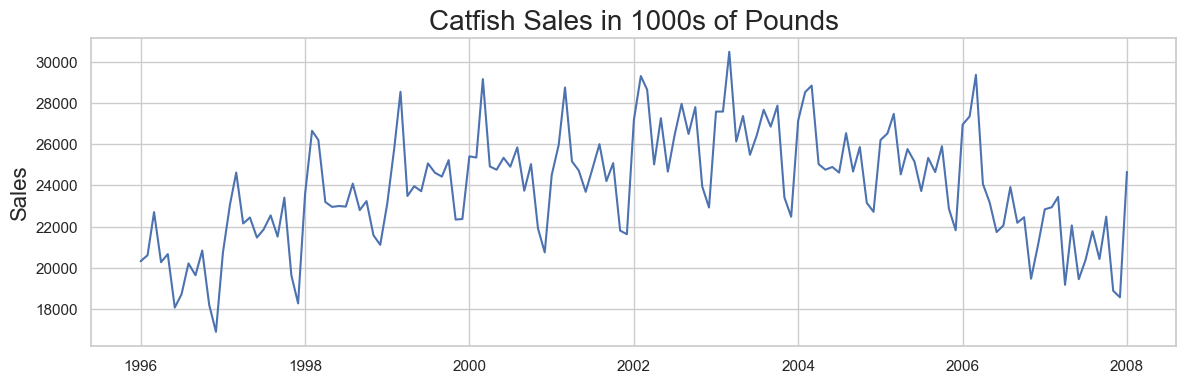

In [7]:
#plot
plt.figure(figsize=(14,4))
plt.plot(lim_catfish_sales)
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)

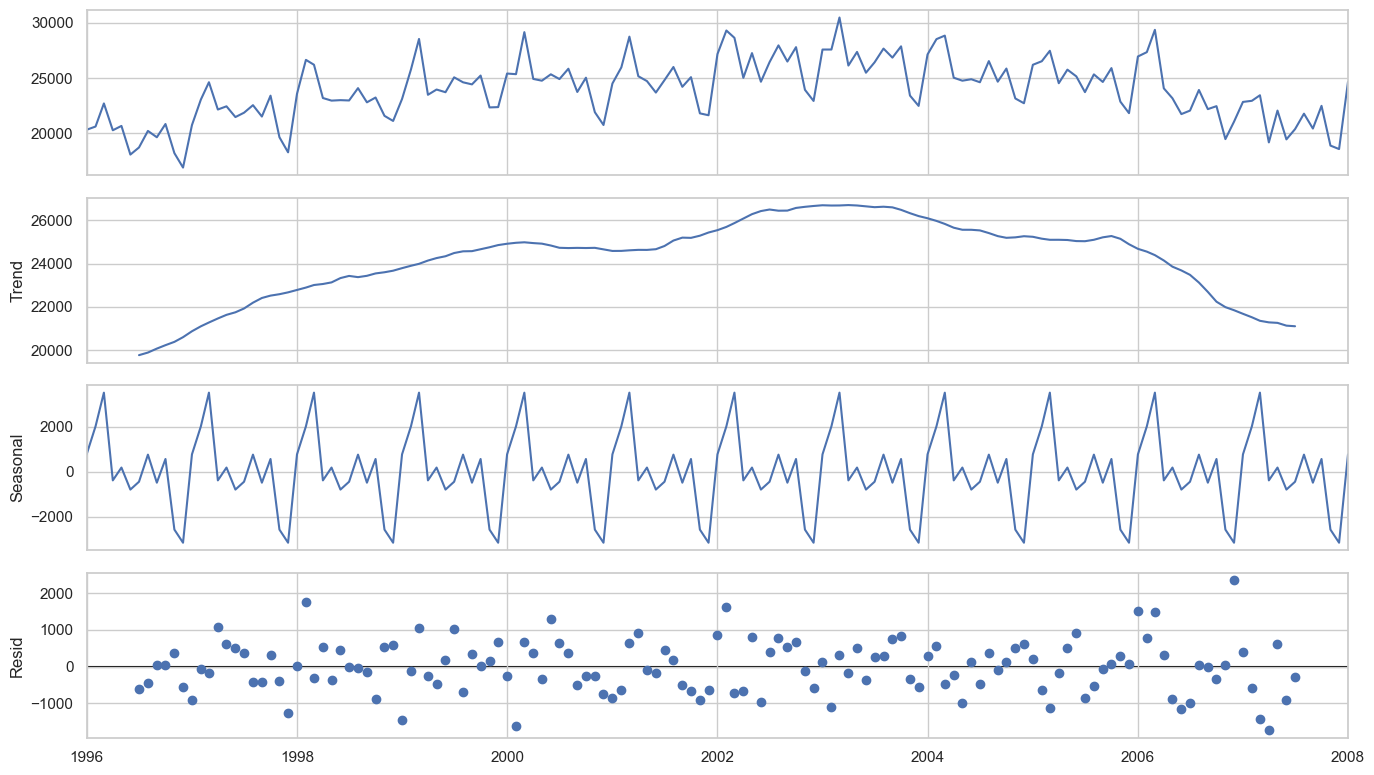

In [8]:
plt.rc('figure',figsize=(14,8))
plt.rc('font',size=15)
result = seasonal_decompose(lim_catfish_sales,model='additive')
fig = result.plot()

In [ ]:
ARIMA -> p d q

In [9]:
def check_stationarity(series, test_name):
    """
    Performs and prints the results of the ADF and KPSS tests.
    
    Args:
        series (pd.Series): The time series to test.
        test_name (str): A descriptive name for the series being tested.
    """
    print(f"\n--- Results for the {test_name} series ---")
    
    # Augmented Dickey-Fuller (ADF) Test
    # H0: The series is non-stationary (has a unit root)
    adf_result = adfuller(series)
    print("ADF Test:")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  P-value: {adf_result[1]:.4f}")
    print("  Interpretation:")
    if adf_result[1] > 0.05:
        print("  --> Fails to reject H0. The series is likely non-stationary.")
    else:
        print("  --> Rejects H0. The series is likely stationary.")
    
    # Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
    # H0: The series is stationary
    try:
        kpss_result = kpss(series, regression='c')
        print("\nKPSS Test:")
        print(f"  Test Statistic: {kpss_result[0]:.4f}")
        print(f"  P-value: {kpss_result[1]:.4f}")
        print("  Interpretation:")
        if kpss_result[1] < 0.05:
            print("  --> Rejects H0. The series is likely non-stationary.")
        else:
            print("  --> Fails to reject H0. The series is likely stationary.")
    except Exception as e:
        print("\nKPSS Test could not be performed due to an error:")
        print(f"  Error: {e}")

In [10]:
check_stationarity(lim_catfish_sales,'Test')


--- Results for the Test series ---
ADF Test:
  Test Statistic: -1.8797
  P-value: 0.3417
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 0.5195
  P-value: 0.0373
  Interpretation:
  --> Rejects H0. The series is likely non-stationary.


In [11]:
diff_series = lim_catfish_sales['Total'].diff().dropna()

Text(0, 0.5, 'Sales')

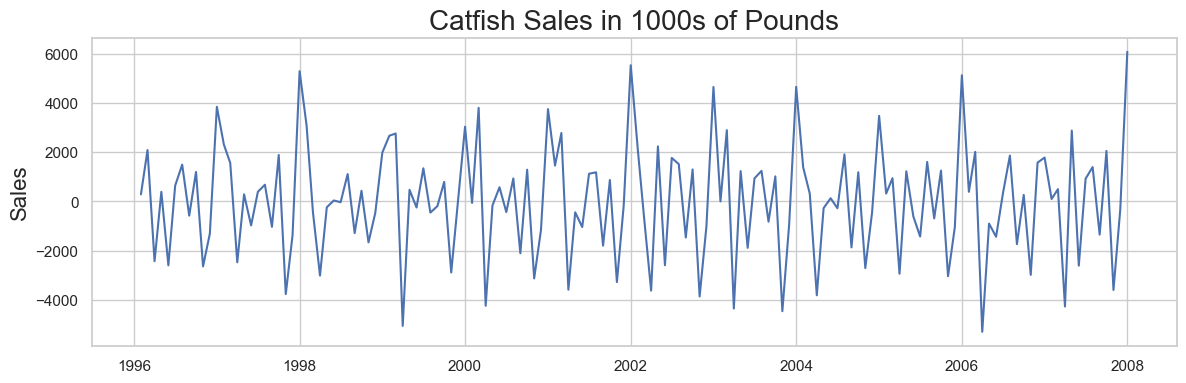

In [12]:
plt.figure(figsize=(14,4))
plt.plot(diff_series)
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)

In [13]:
check_stationarity(diff_series,'Test')


--- Results for the Test series ---
ADF Test:
  Test Statistic: -2.4205
  P-value: 0.1360
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 0.1505
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


In [14]:
second_diff_series = diff_series.diff().dropna()

Text(0, 0.5, 'Sales')

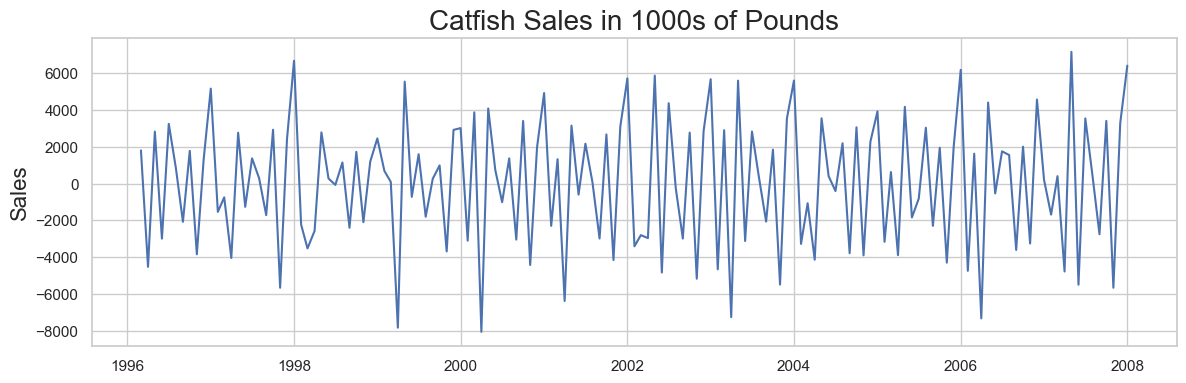

In [15]:
plt.figure(figsize=(14,4))
plt.plot(second_diff_series)
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)

In [16]:
check_stationarity(second_diff_series,'Test')


--- Results for the Test series ---
ADF Test:
  Test Statistic: -7.7320
  P-value: 0.0000
  Interpretation:
  --> Rejects H0. The series is likely stationary.

KPSS Test:
  Test Statistic: 0.2665
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


In [ ]:
d = 2

p, q -> 

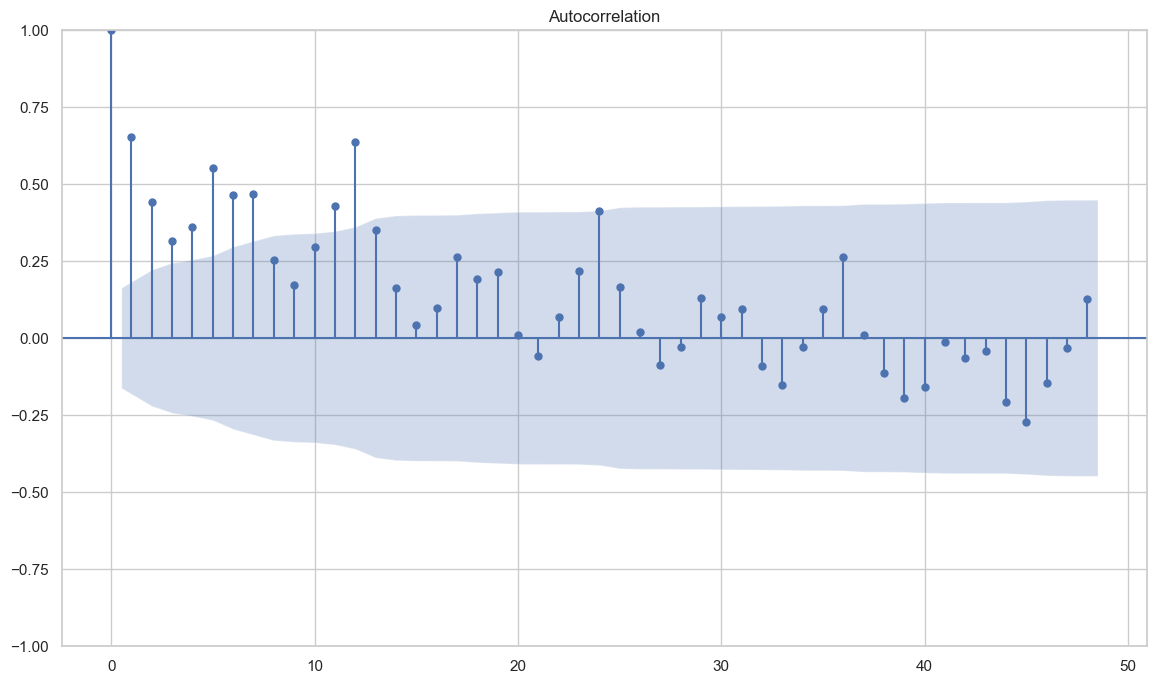

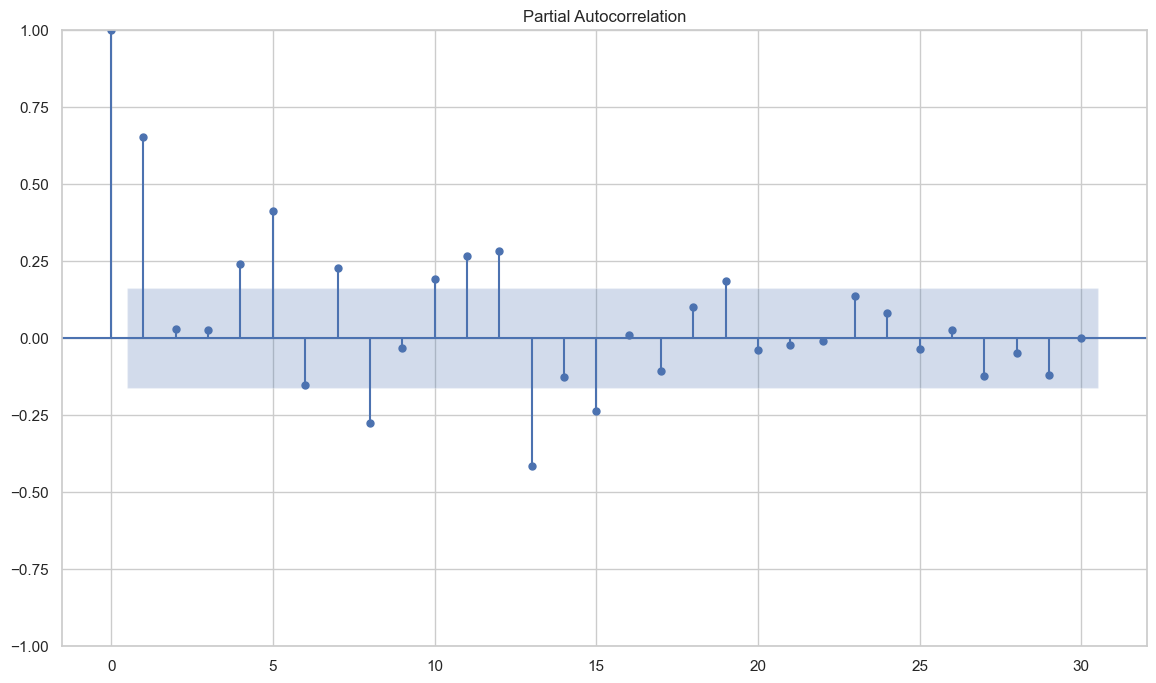

In [17]:
plot_acf(lim_catfish_sales['Total'], lags=48);
plot_pacf(lim_catfish_sales['Total'], lags=30);

In [ ]:
diff_series

<Figure size 1600x400 with 0 Axes>

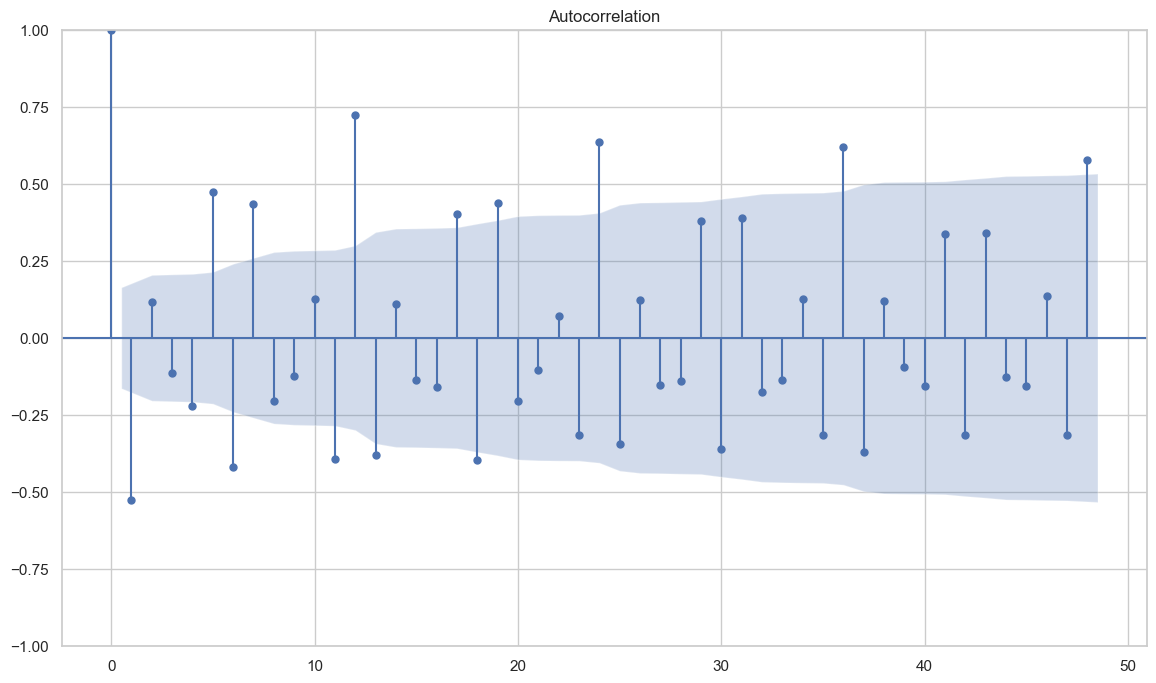

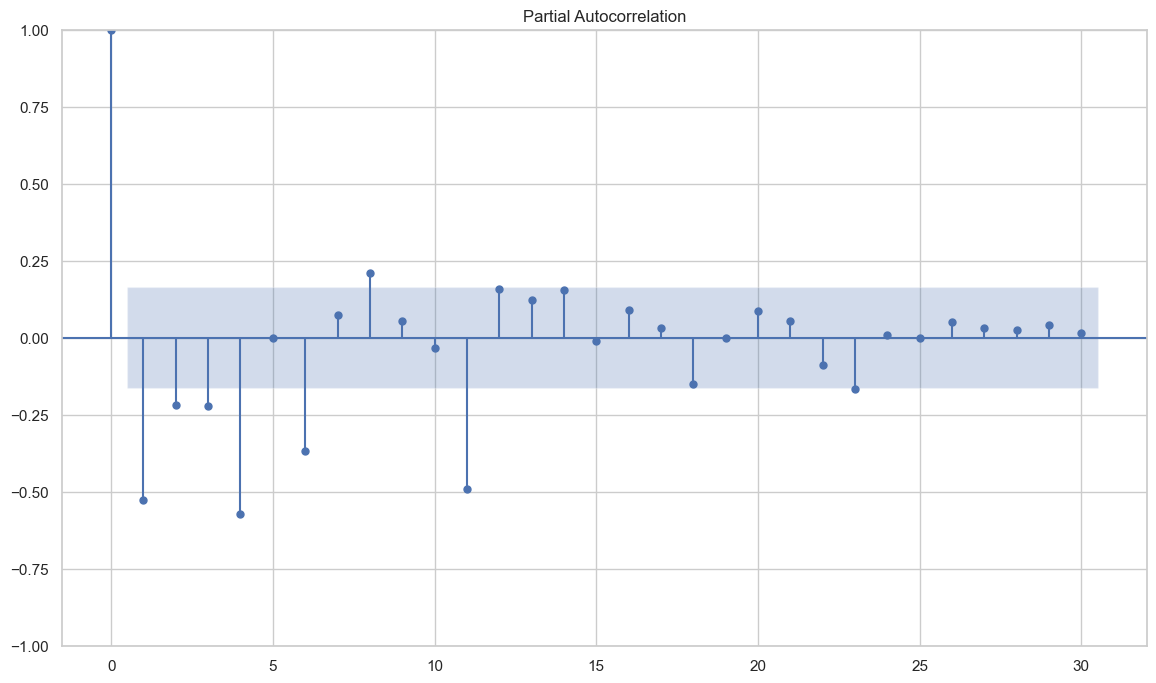

In [21]:
plt.figure(figsize=(16,4))
plot_acf(second_diff_series, lags=48);
plot_pacf(second_diff_series, lags=30);

In [ ]:
d = 2, p =4, q = 1


estimation of parameters :

yt+1 = c + 4 AR + 1 MA

In [29]:
arima = ARIMA(lim_catfish_sales['Total'], order=(4,2,4))
arima_model = arima.fit()
predictions = arima_model.predict()

In [30]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Total   No. Observations:                  145
Model:                 ARIMA(4, 2, 4)   Log Likelihood               -1278.102
Date:                Sat, 23 Aug 2025   AIC                           2574.203
Time:                        16:30:23   BIC                           2600.869
Sample:                    01-01-1996   HQIC                          2585.039
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7561      0.118     -6.406      0.000      -0.987      -0.525
ar.L2          0.1261      0.182      0.692      0.489      -0.231       0.483
ar.L3         -0.0115      0.185     -0.062      0.950      -0.374       0.351
ar.L4         -0.5666      0.113     -5.017      0.000      -0.788      -0.345
ma.L1         -0.2531      0.122     -2.079      0.038      -0.492      -0.014
ma.L2         -1.4168      0.092    -15.427      0.000      -1.597      -1.237
ma.L3         -0.2314      0.137     -1.692      0.091      -0.499       0.037
ma.L4          0.9521      0.098      9.700      0.000       0.760       1.144
sigma2      4.249e+06    1.3e-08   3.27e+14      0.000    4.25e+06    4.25e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.54   Jarque-Bera (JB):                 7.35
Prob(Q):                              0.46   Prob(JB):                         0.03
Heteroskedasticity (H):               0.65   Skew:                             0.22
Prob(H) (two-sided):                  0.13   Kurtosis:                         4.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.77e+30. Standard errors may be unstable.
"""

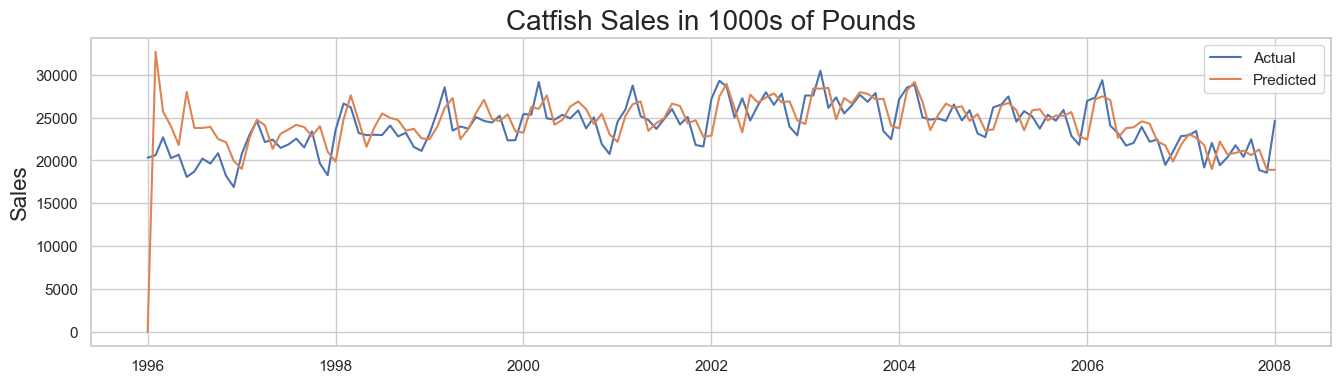

In [24]:
plt.figure(figsize=(16,4))
plt.plot(lim_catfish_sales, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)
plt.legend()

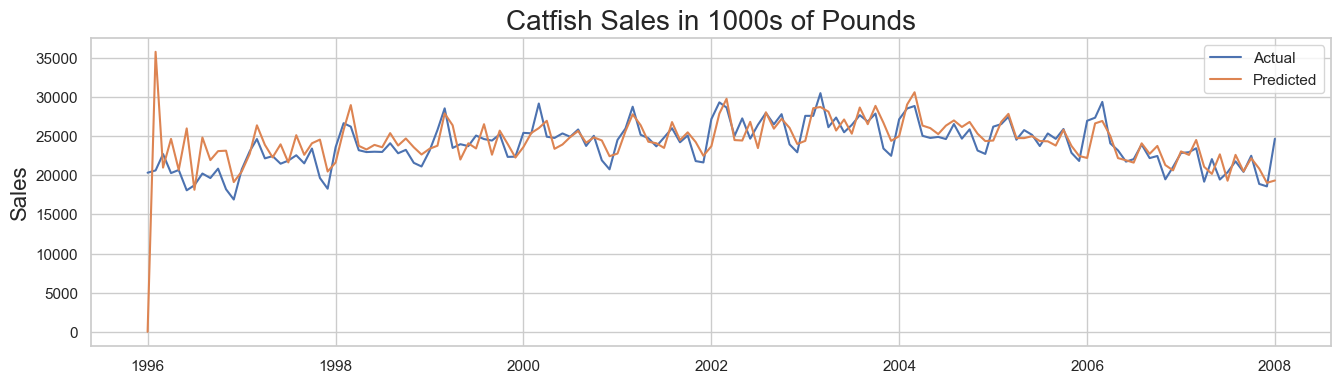

In [31]:
plt.figure(figsize=(16,4))
plt.plot(lim_catfish_sales, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)
plt.legend()

In [32]:
import pmdarima as pm

In [33]:
# The auto_arima function automatically finds the best p, d, and q parameters
model = pm.auto_arima(
    lim_catfish_sales,
    d=2,
    max_p=12,
    max_q=12,
    trace=True, 
    error_action='ignore',  # Do not warn on failure to fit
    suppress_warnings=True, # Do not print warnings
    stepwise=True,
    seasonal=False  # Set to True for SARIMA models
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=2742.198, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=2702.224, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=2740.231, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=2698.459, Time=0.05 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=2691.718, Time=0.05 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=2649.101, Time=0.11 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=2649.620, Time=0.19 sec
 ARIMA(4,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(5,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=2646.863, Time=0.08 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=2689.622, Time=0.04 sec
 ARIMA(5,2,0)(0,0,0)[0]             : AIC=2647.389, Time=0

In [34]:
arima = ARIMA(lim_catfish_sales['Total'], order=(4,2,2))
arima_model = arima.fit()
predictions = arima_model.predict()

In [35]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Total   No. Observations:                  145
Model:                 ARIMA(4, 2, 2)   Log Likelihood               -1298.122
Date:                Sat, 23 Aug 2025   AIC                           2610.245
Time:                        16:37:13   BIC                           2630.985
Sample:                    01-01-1996   HQIC                          2618.673
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6858      0.129     -5.326      0.000      -0.938      -0.433
ar.L2         -0.2940      0.091     -3.226      0.001      -0.473      -0.115
ar.L3         -0.5345      0.093     -5.740      0.000      -0.717      -0.352
ar.L4         -0.5082      0.060     -8.487      0.000      -0.626      -0.391
ma.L1         -0.3839      0.135     -2.847      0.004      -0.648      -0.120
ma.L2         -0.5762      0.144     -3.988      0.000      -0.859      -0.293
sigma2      4.094e+06   5.31e+05      7.713      0.000    3.05e+06    5.13e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.43   Jarque-Bera (JB):                50.88
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               0.52   Skew:                            -0.11
Prob(H) (two-sided):                  0.02   Kurtosis:                         5.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

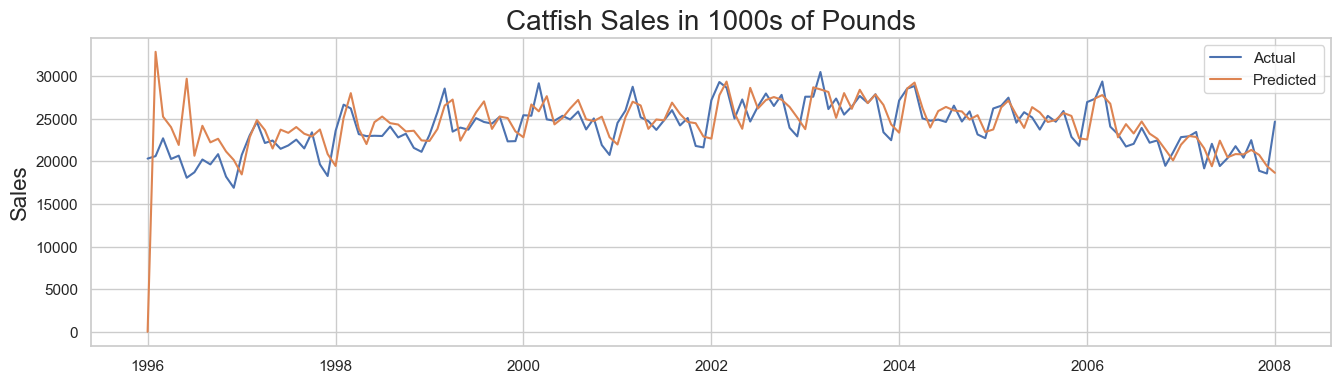

In [36]:
plt.figure(figsize=(16,4))
plt.plot(lim_catfish_sales, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title('Catfish Sales in 1000s of Pounds', fontsize=20)
plt.ylabel('Sales', fontsize=16)
plt.legend()